# Tilaajien käyttösegmenttien löytäminen PROC FASTCLUS -menetelmällä

## Yhteenveto

Teleoperaattorin analytiikkatiimi haluaa segmentoida matkapuhelinliittymäkantansa **kuukausittaisen datankäytön** perusteella asettamatta mielivaltaisia gigatavurajoja. Käyttämällä **PROC FASTCLUS** -menetelmää — SAS:n tehokasta *k*-means-klusterointimenetelmää — annamme datan jakautua itsestään piileviin käyttöluokkiin (kevyt, kohtalainen ja raskas datankäyttäjä). FASTCLUS löytää kunkin segmentin keskipisteen, liittää jokaisen tilaajan lähimpään keskipisteeseen ja raportoi, kuinka selkeästi segmentit erottuvat toisistaan — muuttaen yhden jatkuvan käyttömittarin toimintakelpoiseksi, dataan perustuvaksi segmentoinniksi liittymäsuunnittelua ja kohdennettua markkinointia varten.

## Tietolähteet

Kaikki data luodaan sisäisesti ensimmäisessä DATA-askeleessa - ulkoisia tiedostoja tai verkkokutsuja ei tarvita. Tilaajat poimitaan kolmen komponentin käyttöjakaumasta, jotta löydetyt segmentit voidaan validoida tunnettua todellisuutta vasten.

| Tietojoukko | Rivit | Muuttuja | Tyyppi | Kuvaus |
|---------|------|----------|------|-------------|
| `subscribers` | 1 500 | `id` | Num | Tilaajan tunnus (1-1500) |
| `subscribers` | 1 500 | `data_gb` | Num | Kuukausittainen käytetty mobiilidata, gigatavuina (mittari, jonka mukaan klusterointi tehdään) |
| `subscribers` | 1 500 | `segment_true` | Char | Piilevä segmentti, jota käytettiin arvon *generointiin* (Kevyt ≈ N(3,1²) 50 %, Keskitaso ≈ N(12,3²) 35 %, Raskas ≈ N(35,8²) 15 %); pidetään erillään vain löydettyjen segmenttien validointia varten - todellinen analyytikko ei näkisi tätä muuttujaa |

# Tilaajien käyttösegmenttien löytäminen

Matkapuhelinoperaattoreilla on harvoin selkeää tunnistetta, joka kertoisi *"tämä on raskas datankäyttäjä."* Sen sijaan käytössä on jatkuva mittari — kuukaudessa kulutetut gigatavut — jonka jakauma on **monihuippuinen**: kevyiden, kohtalaisten ja tehokäyttäjien klusterit menevät päällekkäin yhdellä akselilla. **Klusterianalyysi** käsittelee tätä yksittäistä saraketta geometrisena ongelmana: se paikantaa käyttöjakauman luonnolliset massakeskipisteet ja liittää jokaisen tilaajan lähimpään niistä, ilman käsin valittuja raja-arvoja.

Tässä muistikirjassa:

1. Luomme realistisen synteettisen tilaajakannan, jonka datankäyttö tulee kolmesta piilevästä segmentistä.
2. Tarkastelemme käytön marginaalijakaumaa vahvistaaksemme, että se on monihuippuinen.
3. Standardoimme mittarin ja ajamme **PROC FASTCLUS**-menetelmän jakaaksemme tilaajat kolmeen käyttösegmenttiin.
4. Profiloimme kunkin löydetyn segmentin alkuperäisessä Gt-asteikossa ja validoimme löydöksen tunnettua totuutta vasten.

`segment_true`-tunniste generoidaan vain, jotta voimme arvioida klusteroinnin lopussa - tuotannossa sitä ei olisi olemassa.

In [1]:
/* Synteettinen tilaajakanta kolmesta piilevästä käyttösegmentistä. */
/* Kevyet käyttäjät hallitsevat; pieni raskaiden käyttäjien häntä tuottaa suurimman osan liikevaihdosta. */
TIEDOT subscribers;
   CALL streaminit(20260531);
   PITUUS segment_true $12;
   TEE id = 1 ASTI 1500;
      u = rand('uniform');
      JOS u < 0.50 NIIN TEE;                 /* ~50 % kevyitä käyttäjiä  */
         segment_true = 'Kevyt';
         data_gb = rand('normal', 3.0, 1.0);
      LOPPU;
      MUUTEN JOS u < 0.85 NIIN TEE;            /* ~35 % kohtalaisia käyttäjiä */
         segment_true = 'Keskitaso';
         data_gb = rand('normal', 12.0, 3.0);
      LOPPU;
      MUUTEN TEE;                             /* ~15 % raskaita/tehokäyttäjiä */
         segment_true = 'Raskas';
         data_gb = rand('normal', 35.0, 8.0);
      LOPPU;
      JOS data_gb < 0.1 NIIN data_gb = 0.1; /* käyttö ei voi olla negatiivinen */
      TULOSTE;
   LOPPU;
   SÄILYTÄ id data_gb segment_true;
SUORITA;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Ensikatsaus marginaalijakaumaan

Ennen klusterointia summataan yksittäinen vastemuuttuja. Laaja hajonta ja ero keskiarvon ja kevyiden käyttäjien joukon välillä ovat tyypillisiä merkkejä segmenttien sekoituksesta - yksittäinen käyttötaso ei toistaisi sekä tiheää matalan käytön klusteria että pitkää korkean käytön häntää.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   NIMIKE data_gb = "Kuukausittainen datankäyttö (Gt)";
   MUUTTUJA data_gb;
SUORITA;

                                                  The MEANS Procedure

 Variable  Label                                      N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Kuukausittainen datankäyttö (Gt)         100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ----------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Histogrammi tekee monihuippuisuudesta visuaalisen: korkea kevyiden käyttäjien piikki noin 3 Gt:n kohdalla, kohtalaisten käyttäjien kumpu noin 12 Gt:n kohdalla ja harva raskaiden käyttäjien häntä, joka ulottuu yli 30 Gt:n. Nämä kolme huippua ovat juuri ne segmentit, jotka pyydämme klusterointia löytämään. Ydintiheysestimaatin peittokuva jäljittää saman sekoittuneen muodon.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


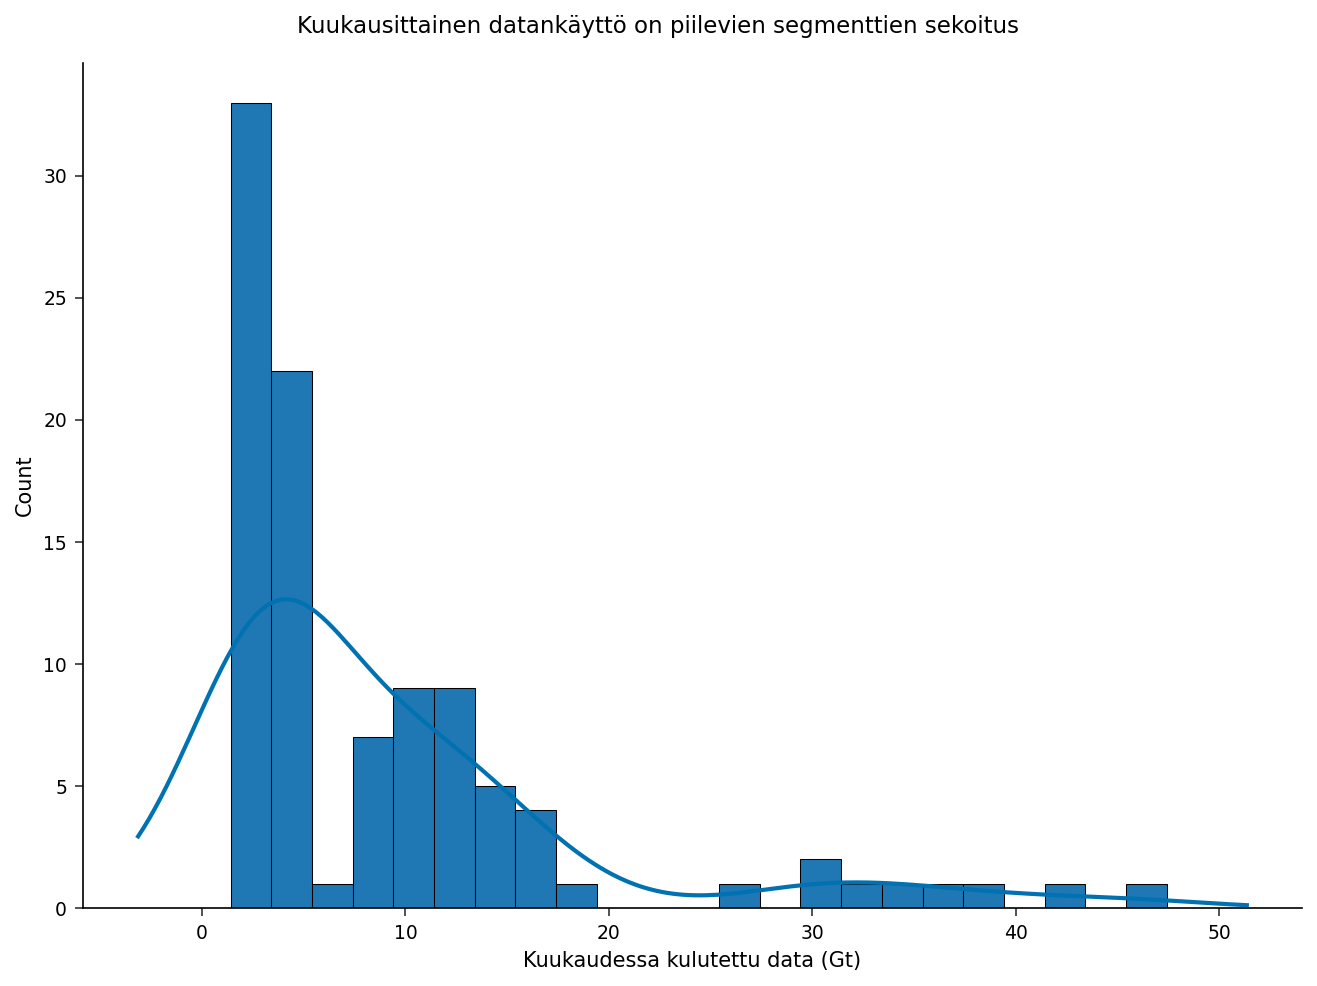

In [3]:
ODS GRAPHICS ON;
PROSEDUURI SGPLOT TIEDOT=subscribers;
   OTSIKKO "Kuukausittainen datankäyttö on piilevien segmenttien sekoitus";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS NIMIKE="Kuukaudessa kulutettu data (Gt)";
SUORITA;
OTSIKKO;
ODS GRAPHICS OFF;

## Käytön saattaminen yhteiselle asteikolle

*k*-means jakaa pisteet euklidisen etäisyyden mukaan, joten muuttujan raaka-asteikko ohjaa lopputulosta. Yhden mittarin tapauksessa tämä vain uudelleenkeskittää akselin, mutta standardointi keskiarvoon 0 / keskihajontaan 1 **PROC STANDARD** -menetelmällä on tapa, joka pitää työnkulun oikeana heti, kun toinen käyttömittari (puheminuutit, roaming-päivät) lisätään. Klusteroimme standardoidun sarakkeen ja raportoimme tulokset takaisin alkuperäisessä Gt-asteikossa.

In [4]:
PROSEDUURI STANDARD TIEDOT=subscribers out=subs_std mean=0 std=1;
   MUUTTUJA data_gb;
SUORITA;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Tilaajien jakaminen kolmeen käyttösegmenttiin

Kevyen/kohtalaisen/raskaan tason toimialatuntemuksen ohjaamana pyydämme **PROC FASTCLUS** -menetelmältä arvoa `MAXCLUSTERS=3`. Menetelmä siementää kolme keskipistettä, liittää jokaisen tilaajan lähimpään niistä, laskee keskipisteet uudelleen ja iteroi, kunnes liittymiset lakkaavat muuttumasta (`CONVERGE=` yhdessä `MAXITER=`-katon kanssa). `SEED=` tekee alustuksesta toistettavan. `OUT=`-tietojoukko kantaa jokaisen tilaajan `CLUSTER`-tunnisteen ja sen `DISTANCE`-etäisyyden liitettyyn keskipisteeseen; `MEAN=` kirjoittaa segmenttien keskipisteet.

Lue menetelmän diagnostiikka erottelun laadusta: korkea **selitysaste (R-Squared)** (segmenttien selittämä osuus käytön kokonaisvaihtelusta) ja suuri **Pseudo F** viittaavat molemmat hyvin erottuviin, tiiviisiin segmentteihin.

In [5]:
PROSEDUURI FASTCLUS TIEDOT=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   MUUTTUJA data_gb;
   OTSIKKO "Kolme käyttösegmenttiä k-means-menetelmällä";
SUORITA;
OTSIKKO;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Löydettyjen segmenttien profilointi

Klusteritunnisteet ovat käyttökelpoisia vasta, kun kuvaamme kunkin segmentin liiketoiminnan termein. Yhdistämme liitokset takaisin alkuperäiseen (standardoimattomaan) käyttöön ja summaamme kunkin segmentin koon ja tyypillisen kulutuksen Gt-asteikolla - luvut, joiden mukaan liittymäsuunnittelu- tai markkinointitiimi todella toimii.

In [6]:
TIEDOT memberships;
   YHDISTÄ subscribers
         clusters(SÄILYTÄ=id CLUSTER distance);
   MUKAAN id;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=memberships n mean MIN MAX maxdec=2;
   LUOKKA CLUSTER;
   MUUTTUJA data_gb distance;
   NIMIKE CLUSTER = "Klusteri" data_gb = "Datankäyttö (Gt)" distance = "Etäisyys keskipisteeseen";
SUORITA;

PROSEDUURI TULOSTA TIEDOT=memberships(obs=10) noobs NIMIKE;
   MUUTTUJA id data_gb CLUSTER distance segment_true;
   NIMIKE id = "Tilaajan tunnus" data_gb = "Datankäyttö (Gt)" CLUSTER = "Klusteri"
         distance = "Etäisyys keskipisteeseen" segment_true = "Todellinen segmentti";
SUORITA;

                                                  The MEANS Procedure

                                     Analysis Variable : data_gb Datankäyttö (Gt)

        Klusteri          N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                 Analysis Variable : DISTANCE Etäisyys keskipisteeseen

        Klusteri          N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09   


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Löydettyjen segmenttien validointi

Koska tämä on synteettistä dataa, pidimme `segment_true`-tunnisteen erillään - se tunniste, jota käytettiin kunkin tilaajan generointiin. Mallin löytämän `CLUSTER`-tunnisteen ristiintaulukointi todellista segmenttiä vasten näyttää, kuinka selkeästi jako erotti populaation. Vahva keskittyminen yhteen klusteri-segmentti-vastaavuuteen osoittaa hyvää löydöstä; diagonaalin ulkopuolinen massa keskittyy sinne, missä kevyt/kohtalainen- tai kohtalainen/raskas-rajat menevät päällekkäin.

In [7]:
PROSEDUURI FREKVENSSIT TIEDOT=memberships;
   NIMIKE CLUSTER = "Klusteri" segment_true = "Todellinen segmentti";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
SUORITA;

                                                   The FREQ Procedure

Table of Klusteri by Todellinen segmentti

Klusteri | Keskitaso |     Kevyt |    Raskas |      Total
---------+-----------+-----------+-----------+-----------
1        |         3 |        54 |         0 |         57
---------+-----------+-----------+-----------+-----------
2        |         0 |         0 |         9 |          9
---------+-----------+-----------+-----------+-----------
3        |        33 |         0 |         1 |         34
---------+-----------+-----------+-----------+-----------
Total    |        36 |        54 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Tulosten tulkinta

- **Segmenttien keskipisteet.** Kolme klusteria osuvat lähes tarkalleen suunniteltuihin käyttötasoihin - kevyet käyttäjät lähellä **3 Gt:aa**, kohtalaiset käyttäjät lähellä **13 Gt:aa** ja raskaat käyttäjät lähellä **37 Gt:aa** - määrittäen sekä *missä* kukin segmentti sijaitsee että *kuinka suuri* se on. Pieni raskaiden käyttäjien segmentti, vaikka onkin vain murto-osa tilaajista, vastaa suhteettoman suuresta osuudesta kokonaisdatasta - klassinen verkkokapasiteetti- ja premium-liittymäpäätösten ajuri.
- **Erottelun laatu.** PROC FASTCLUS raportoi korkean kokonais-**selitysasteen (R-Squared)** ja suuren **Pseudo F** -arvon, mikä vahvistaa, että kolme segmenttiä ovat tiiviitä ja hyvin erottuvia eivätkä mielivaltaisen rajauksen artefakteja. Yksi taso jättäisi suurimman osan tästä käytön vaihtelusta selittämättä.
- **Ei käsin valittuja raja-arvoja.** Segmentointi syntyy itse käyttöjakauman geometriasta. Menetelmä valitsi rajat; me valitsimme vain *kuinka monta* tasoa pyydämme, ohjattuna histogrammin ilmeisestä kolmihuippuisesta muodosta.
- **Toimintakelpoinen tulos.** `OUT=`-tietojoukko antaa jokaiselle tilaajalle segmenttitunnisteen *ja* `DISTANCE`-etäisyyden sen keskipisteeseen. Tilaajat, jotka ovat kaukana mistä tahansa keskipisteestä - tai sijaitsevat kevyt/kohtalainen-rajalla - ovat juuri niitä asiakkaita, joita kannattaa A/B-testata lisämyyntitarjouksilla, kun taas tiiviisti klusteroituneet raskaat käyttäjät ovat vahvoja ehdokkaita kapasiteettitietoisiin tai rajattomiin liittymiin.

Lyhyesti: PROC FASTCLUS muuttaa yhden jatkuvan käyttömittarin dataan perustuvaksi segmentoinniksi - ilman käsin valittuja Gt-raja-arvoja - ja ristiintaulukointi erillään pidettyä totuutta vasten vahvistaa, että segmentit löydetään luotettavasti.